In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

sys.path.append("../src")

from utils import (
    carregar_dados,
    padronizar_colunas,
    criar_variaveis_analiticas,
    calcular_ataques,
    calcular_defesas,
    resumo_resultados,
    media_gols
)

In [2]:
caminho_arquivo = "../data/raw/brasileirao.csv"

df = carregar_dados(caminho_arquivo)
df.head()

,ID,rodada,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,NaN
1,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,NaN
2,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,NaN
3,4,1,30/03/2003,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA,NaN
4,5,1,30/03/2003,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP,NaN


In [3]:
df.columns.tolist()

['ID',
 'rodada',
 'data',
 'hora',
 'mandante',
 'visitante',
 'formacao_mandante',
 'formacao_visitante',
 'tecnico_mandante',
 'tecnico_visitante',
 'vencedor',
 'arena',
 'mandante_Placar',
 'visitante_Placar',
 'mandante_Estado',
 'visitante_Estado',
 'arrecadacao']

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9165 entries, 0 to 9164
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  9165 non-null   int64  
 1   rodada              9165 non-null   int64  
 2   data                9165 non-null   str    
 3   hora                9165 non-null   str    
 4   mandante            9165 non-null   str    
 5   visitante           9165 non-null   str    
 6   formacao_mandante   4190 non-null   str    
 7   formacao_visitante  4190 non-null   str    
 8   tecnico_mandante    4555 non-null   str    
 9   tecnico_visitante   4555 non-null   str    
 10  vencedor            9165 non-null   str    
 11  arena               9165 non-null   str    
 12  mandante_Placar     9165 non-null   int64  
 13  visitante_Placar    9165 non-null   int64  
 14  mandante_Estado     9165 non-null   str    
 15  visitante_Estado    9165 non-null   str    
 16  arrecadacao      

In [5]:
df.columns.tolist()

['ID',
 'rodada',
 'data',
 'hora',
 'mandante',
 'visitante',
 'formacao_mandante',
 'formacao_visitante',
 'tecnico_mandante',
 'tecnico_visitante',
 'vencedor',
 'arena',
 'mandante_Placar',
 'visitante_Placar',
 'mandante_Estado',
 'visitante_Estado',
 'arrecadacao']

In [6]:
df = padronizar_colunas(df)
df.columns.tolist()

['ID',
 'matchday',
 'match_date',
 'hora',
 'home_team',
 'away_team',
 'formacao_mandante',
 'formacao_visitante',
 'tecnico_mandante',
 'tecnico_visitante',
 'vencedor',
 'arena',
 'home_goals',
 'away_goals',
 'mandante_Estado',
 'visitante_Estado',
 'arrecadacao']

In [10]:
df = criar_variaveis_analiticas(df)
df.head()

,ID,matchday,match_date,hora,home_team,away_team,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,home_goals,away_goals,mandante_Estado,visitante_Estado,arrecadacao,total_goals,match_result
0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,NaN,6,Casa
1,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,NaN,2,Casa
2,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,NaN,2,Empate
3,4,1,30/03/2003,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA,NaN,4,Empate
4,5,1,30/03/2003,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP,NaN,2,Empate


In [11]:
print("Quantidade de jogos:", len(df))
print("Média de gols por partida:", round(media_gols(df), 2))

Quantidade de jogos: 9165
Média de gols por partida: 2.56


In [12]:
resultados = resumo_resultados(df)
resultados

match_result
Casa      4550
Empate    2421
Fora      2194
Name: count, dtype: int64

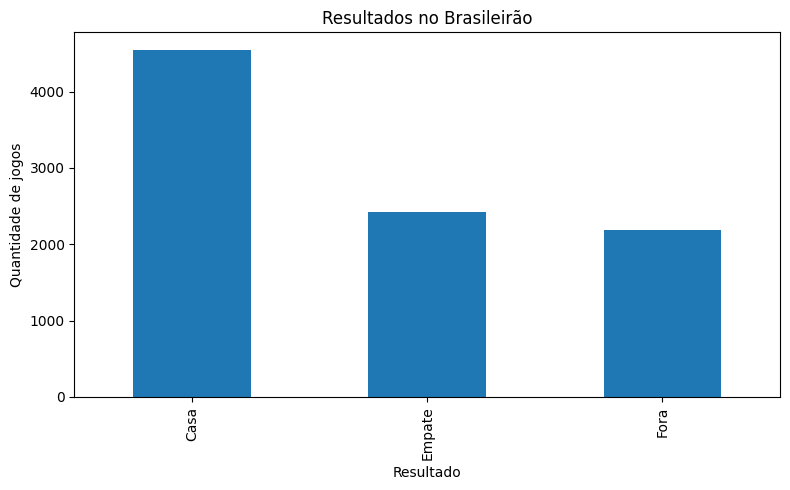

In [13]:
plt.figure(figsize=(8, 5))
resultados.plot(kind="bar")
plt.title("Resultados no Brasileirão")
plt.xlabel("Resultado")
plt.ylabel("Quantidade de jogos")
plt.tight_layout()
plt.show()

In [14]:
ataques = calcular_ataques(df)
ataques.head(10)

home_team
Flamengo         1308
Sao Paulo        1259
Santos           1223
Atletico-MG      1221
Palmeiras        1203
Fluminense       1181
Internacional    1138
Cruzeiro         1111
Gremio           1110
Corinthians      1095
dtype: int64

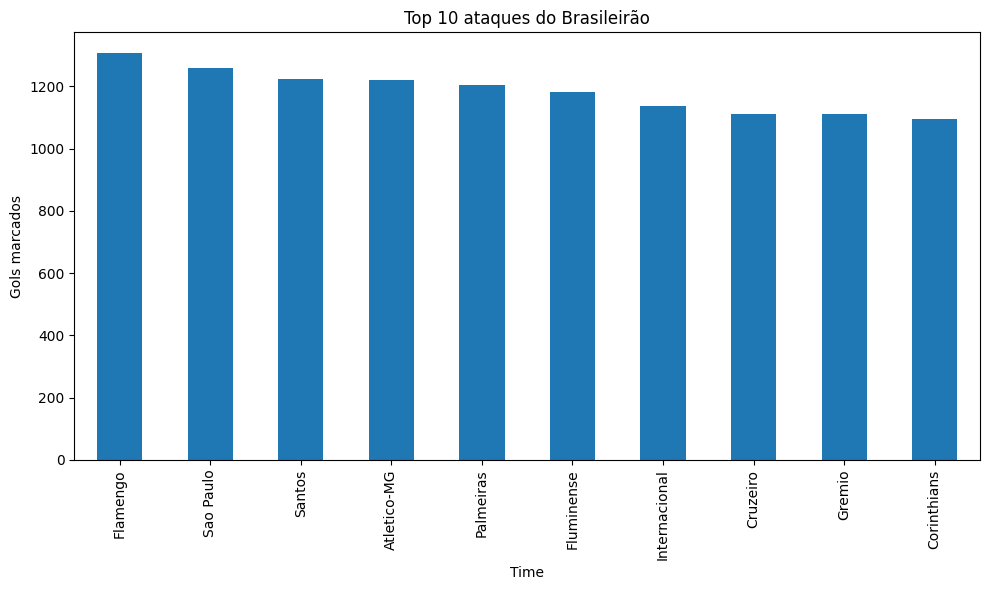

In [15]:
plt.figure(figsize=(10, 6))
ataques.head(10).plot(kind="bar")
plt.title("Top 10 ataques do Brasileirão")
plt.xlabel("Time")
plt.ylabel("Gols marcados")
plt.tight_layout()
plt.show()

In [16]:
defesas = calcular_defesas(df)
defesas.head(10)

home_team
Mirassol            39
Joinville           48
Barueri             52
CSA                 58
Santo Andre         61
Gremio Prudente     64
Ipatinga            67
Brasiliense         68
America-RN          80
Santa Cruz         145
dtype: int64

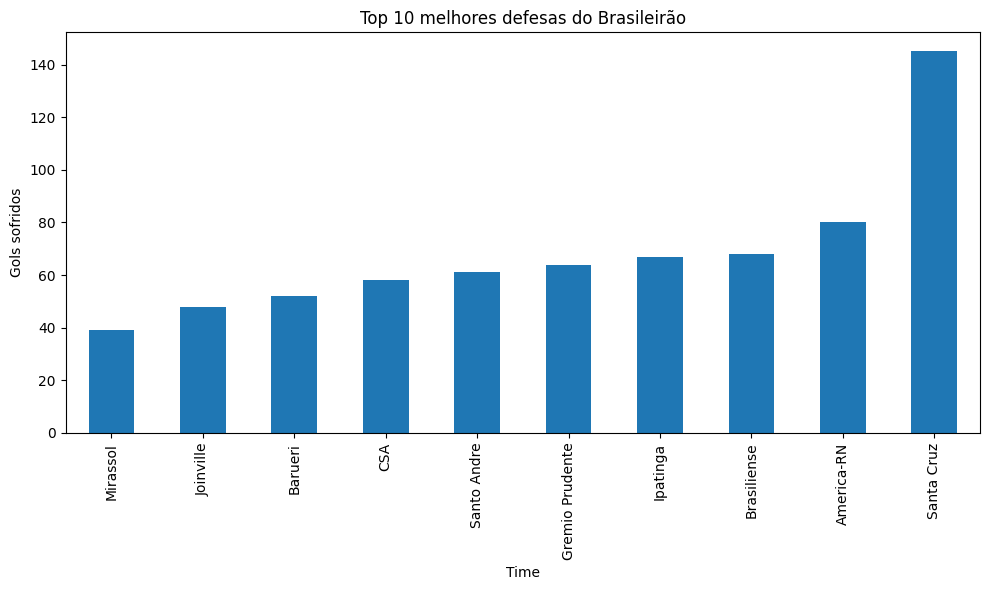

In [17]:
plt.figure(figsize=(10, 6))
defesas.head(10).plot(kind="bar")
plt.title("Top 10 melhores defesas do Brasileirão")
plt.xlabel("Time")
plt.ylabel("Gols sofridos")
plt.tight_layout()
plt.show()

In [21]:
df["match_date"] = pd.to_datetime(df["match_date"])

df["season"] = df["match_date"].dt.year

df.head()

C:\Users\Gustavo Reis\AppData\Local\Temp\ipykernel_20752\533968827.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["match_date"] = pd.to_datetime(df["match_date"])


,ID,matchday,match_date,hora,home_team,away_team,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,home_goals,away_goals,mandante_Estado,visitante_Estado,arrecadacao,total_goals,match_result,season
0,1,1,2003-03-29,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,NaN,6,Casa,2003
1,2,1,2003-03-29,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,NaN,2,Casa,2003
2,3,1,2003-03-30,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,NaN,2,Empate,2003
3,4,1,2003-03-30,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA,NaN,4,Empate,2003
4,5,1,2003-03-30,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP,NaN,2,Empate,2003


In [22]:
df["season"].unique()

array([2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024,
       2025], dtype=int32)

In [24]:
media_por_temporada = df.groupby("season")["total_goals"].mean().sort_index()
media_por_temporada

season
2003    2.884058
2004    2.778986
2005    3.140693
2006    2.710526
2007    2.755263
2008    2.723684
2009    2.878947
2010    2.573684
2011    2.676316
2012    2.473684
2013    2.463158
2014    2.263158
2015    2.360526
2016    2.406332
2017    2.428947
2018    2.176316
2019    2.305263
2020    2.440299
2021    2.300813
2022    2.381579
2023    2.489474
2024    2.444737
2025    2.523684
Name: total_goals, dtype: float64

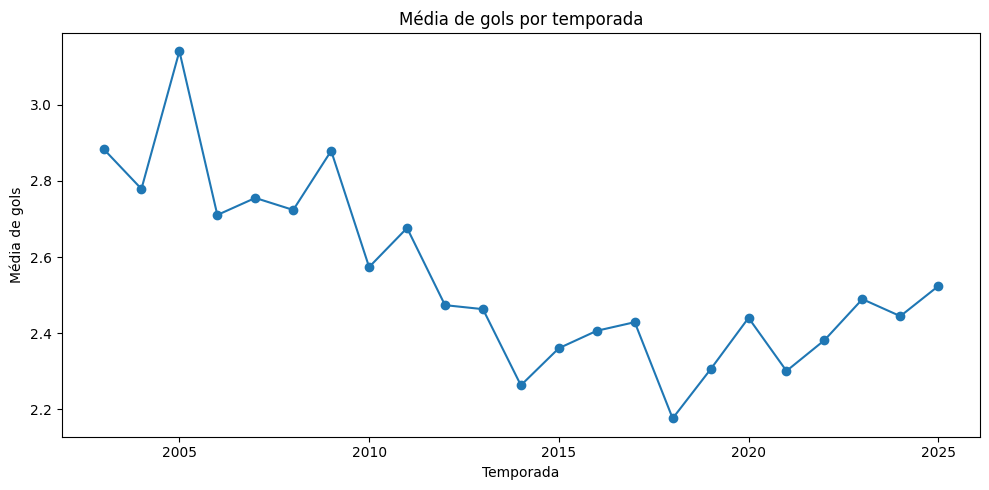

In [25]:
if "season" in df.columns:
    plt.figure(figsize=(10, 5))
    media_por_temporada.plot(kind="line", marker="o")
    plt.title("Média de gols por temporada")
    plt.xlabel("Temporada")
    plt.ylabel("Média de gols")
    plt.tight_layout()
    plt.show()

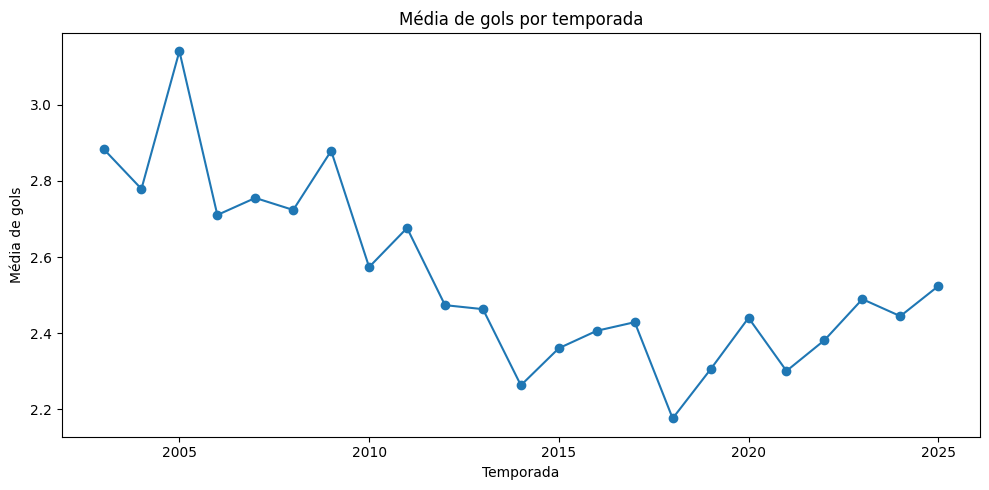

In [26]:
plt.figure(figsize=(10, 5))
media_por_temporada.plot(kind="line", marker="o")
plt.title("Média de gols por temporada")
plt.xlabel("Temporada")
plt.ylabel("Média de gols")

plt.tight_layout()
plt.savefig("../images/media_gols_temporada.png")

plt.show()

In [27]:
top_ataque_por_ano = (
    df.groupby(["season", "home_team"])["home_goals"].sum()
    .reset_index()
    .sort_values(["season", "home_goals"], ascending=[True, False])
)

top_ataque_por_ano = top_ataque_por_ano.groupby("season").first()

top_ataque_por_ano.head(10)

,home_team,home_goals
season,,
2003,Cruzeiro,61
2004,Santos,64
2005,Athletico-PR,49
2006,Gremio,40
2007,Cruzeiro,43
2008,Flamengo,42
2009,Gremio,53
2010,Corinthians,41
2011,Coritiba,40


In [28]:
df["gols_sofridos"] = df["away_goals"]

top_defesa_por_ano = (
    df.groupby(["season", "home_team"])["gols_sofridos"].sum()
    .reset_index()
    .sort_values(["season", "gols_sofridos"], ascending=[True, True])
)

top_defesa_por_ano = top_defesa_por_ano.groupby("season").first()

top_defesa_por_ano.head(10)

,home_team,gols_sofridos
season,,
2003,Sao Caetano,14
2004,Flamengo,17
2005,Internacional,22
2006,Santos,12
2007,Sao Paulo,8
2008,Gremio,10
2009,Flamengo,11
2010,Ceara,12
2011,Vasco,12


In [29]:
top_defesa_por_ano.to_csv("../data/processed/melhores_defesas_por_ano.csv")

In [30]:
top_ataque_por_ano.to_csv("../data/processed/melhores_ataques_por_ano.csv")

In [31]:
plt.savefig("../images/media_gols_temporada.png")

<Figure size 640x480 with 0 Axes>

## Insights principais

- Observa-se uma queda na média de gols entre 2012 e 2018
- Há uma recuperação gradual após 2020
- Times com melhores defesas variam ao longo dos anos, mostrando equilíbrio competitivo
- O Brasileirão apresenta mudanças de padrão ao longo do tempo
- Em 2003 foi o ano com mais gols marcados.